# Расчеты 1-14

Этот ноутбук пошагово показывает полный практический анализ временных рядов. Мы идем от чтения данных и базовой диагностики к причинности, выбору модели, оцениванию, проверке качества и короткой экономической интерпретации.

## Загрузка

Сначала подключаем библиотеки и читаем итоговый датасет. Здесь же задаем короткие названия переменных, чтобы дальше таблицы и графики было проще читать.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from arch.unitroot import PhillipsPerron
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen

from read_dataset import load_dataset

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

names = {
    'cpi_all_items_index_2010_100': 'IPC',
    'net_foreign_assets_bln_rub': 'NFA',
    'm2_bln_rub': 'M2',
}
cols = list(names)
FIGURE_DIR = Path('report_figures')
FIGURE_DIR.mkdir(exist_ok=True)

df = load_dataset()
df

,date,cpi_all_items_index_2010_100,net_foreign_assets_bln_rub,m2_bln_rub
0,2013-01-01,118.40,1546.894,26348.7
1,2013-02-01,119.07,1716.309,26768.4
2,2013-03-01,119.48,1777.340,27198.6
3,2013-04-01,120.09,1871.582,27377.1
4,2013-05-01,120.89,2320.501,27593.4
5,2013-06-01,121.39,2062.333,28212.3
6,2013-07-01,122.39,2057.608,28443.9
7,2013-08-01,122.57,1947.753,28499.9
8,2013-09-01,122.82,1748.925,28352.6
9,2013-10-01,123.53,1746.729,28276.4


**Вывод.** Датасет успешно загружен. В работе 3 ряда: `IPC`, `NFA` и `M2` на месячном интервале `2013-01` - `2015-06`.

## Проверка

Перед анализом важно убедиться, что данные действительно готовы к работе: даты распознаны правильно, пропусков нет, а каждая колонка имеет ожидаемый числовой тип.

In [2]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          30 non-null     datetime64[ns]
 1   cpi_all_items_index_2010_100  30 non-null     float64       
 2   net_foreign_assets_bln_rub    30 non-null     float64       
 3   m2_bln_rub                    30 non-null     float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 1.1 KB


date                            0
cpi_all_items_index_2010_100    0
net_foreign_assets_bln_rub      0
m2_bln_rub                      0
dtype: int64

**Вывод.** Технически данные готовы к анализу: типы колонок корректные, даты читаются правильно, пропусков нет. Это значит, что дальше можно интерпретировать результаты без дополнительной очистки.

## Графики уровней

Здесь мы смотрим на ряды в исходном виде. Такой график нужен, чтобы увидеть тренд, возможные скачки и понять, насколько ряд визуально похож на стационарный или нестационарный.

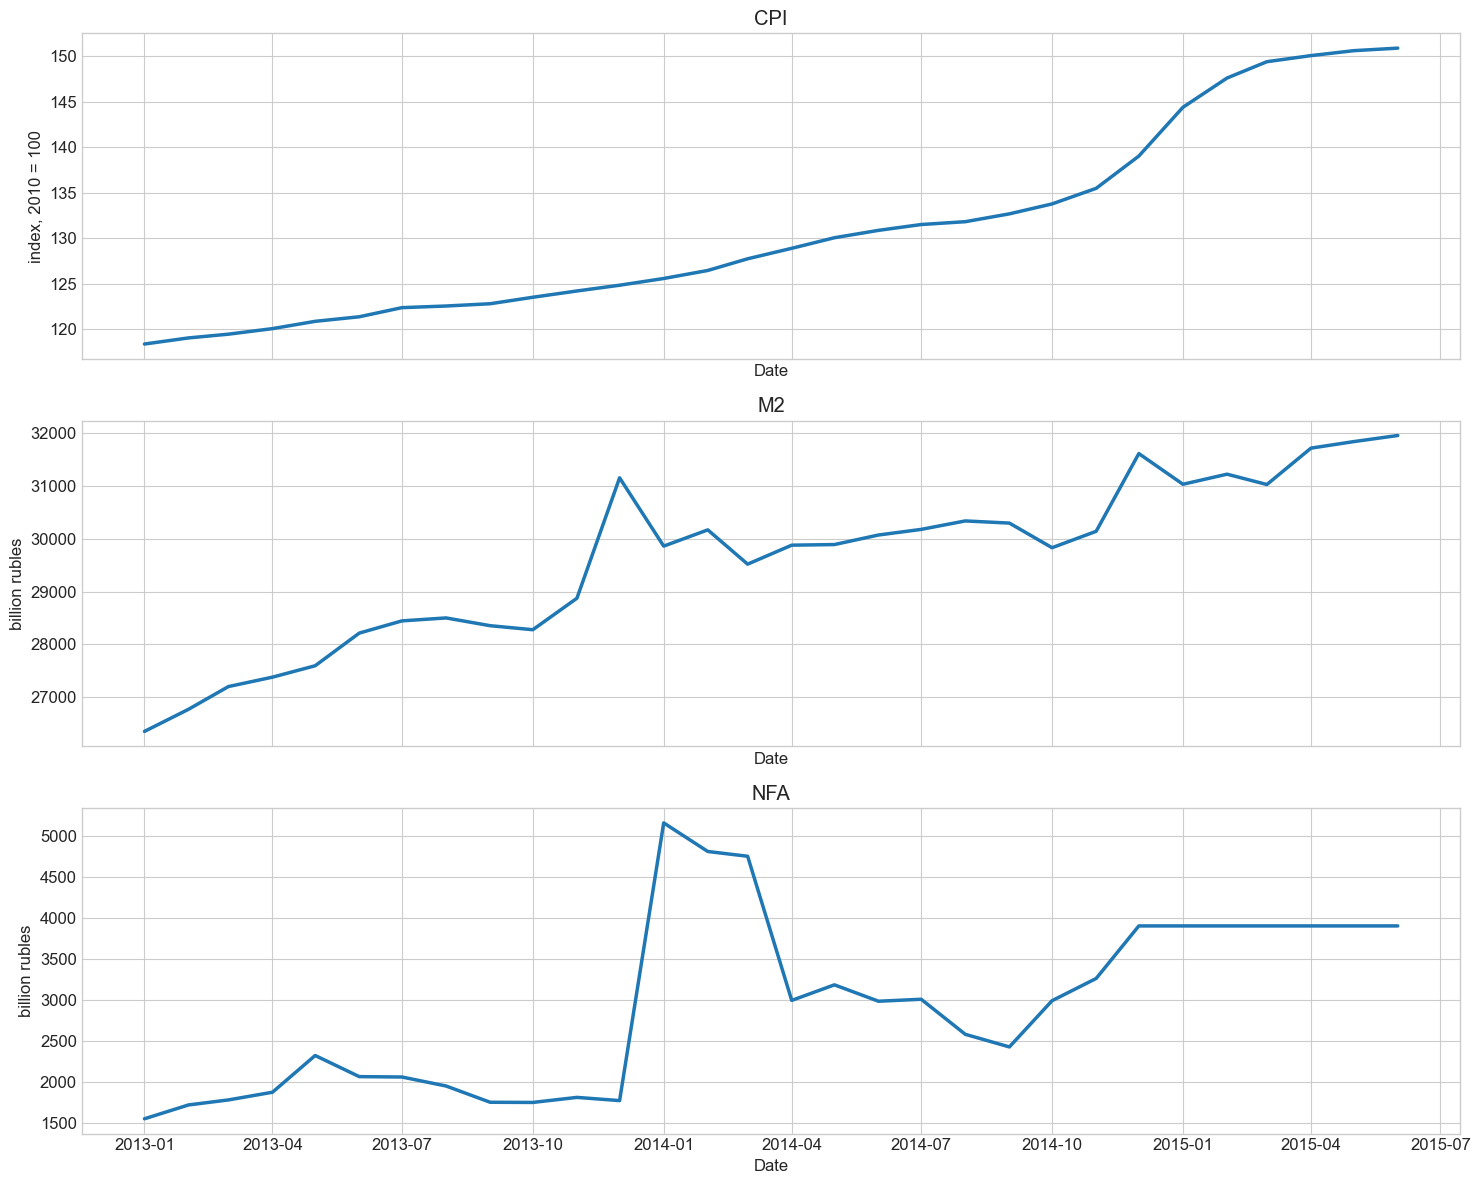

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
columns = [
    ('cpi_all_items_index_2010_100', 'CPI', 'index, 2010 = 100'),
    ('m2_bln_rub', 'M2', 'billion rubles'),
    ('net_foreign_assets_bln_rub', 'NFA', 'billion rubles'),
]

for ax, (col, title, ylabel) in zip(axes, columns):
    ax.plot(df['date'], df[col], linewidth=2.5)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Date')

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'levels.png', dpi=200, bbox_inches='tight')


**Вывод.** На графиках уровней видно общий восходящий тренд у `IPC` и `M2`. `NFA` ведет себя заметно более рвано: в нем есть сильные колебания и скачки, поэтому именно этот ряд, скорее всего, будет вести себя менее стабильно в модели.

## Логи

Логарифмы часто используют во временных рядах, потому что они делают изменения более сопоставимыми во времени. Кроме того, в логах удобнее интерпретировать приросты и строить модели для темпов изменения.

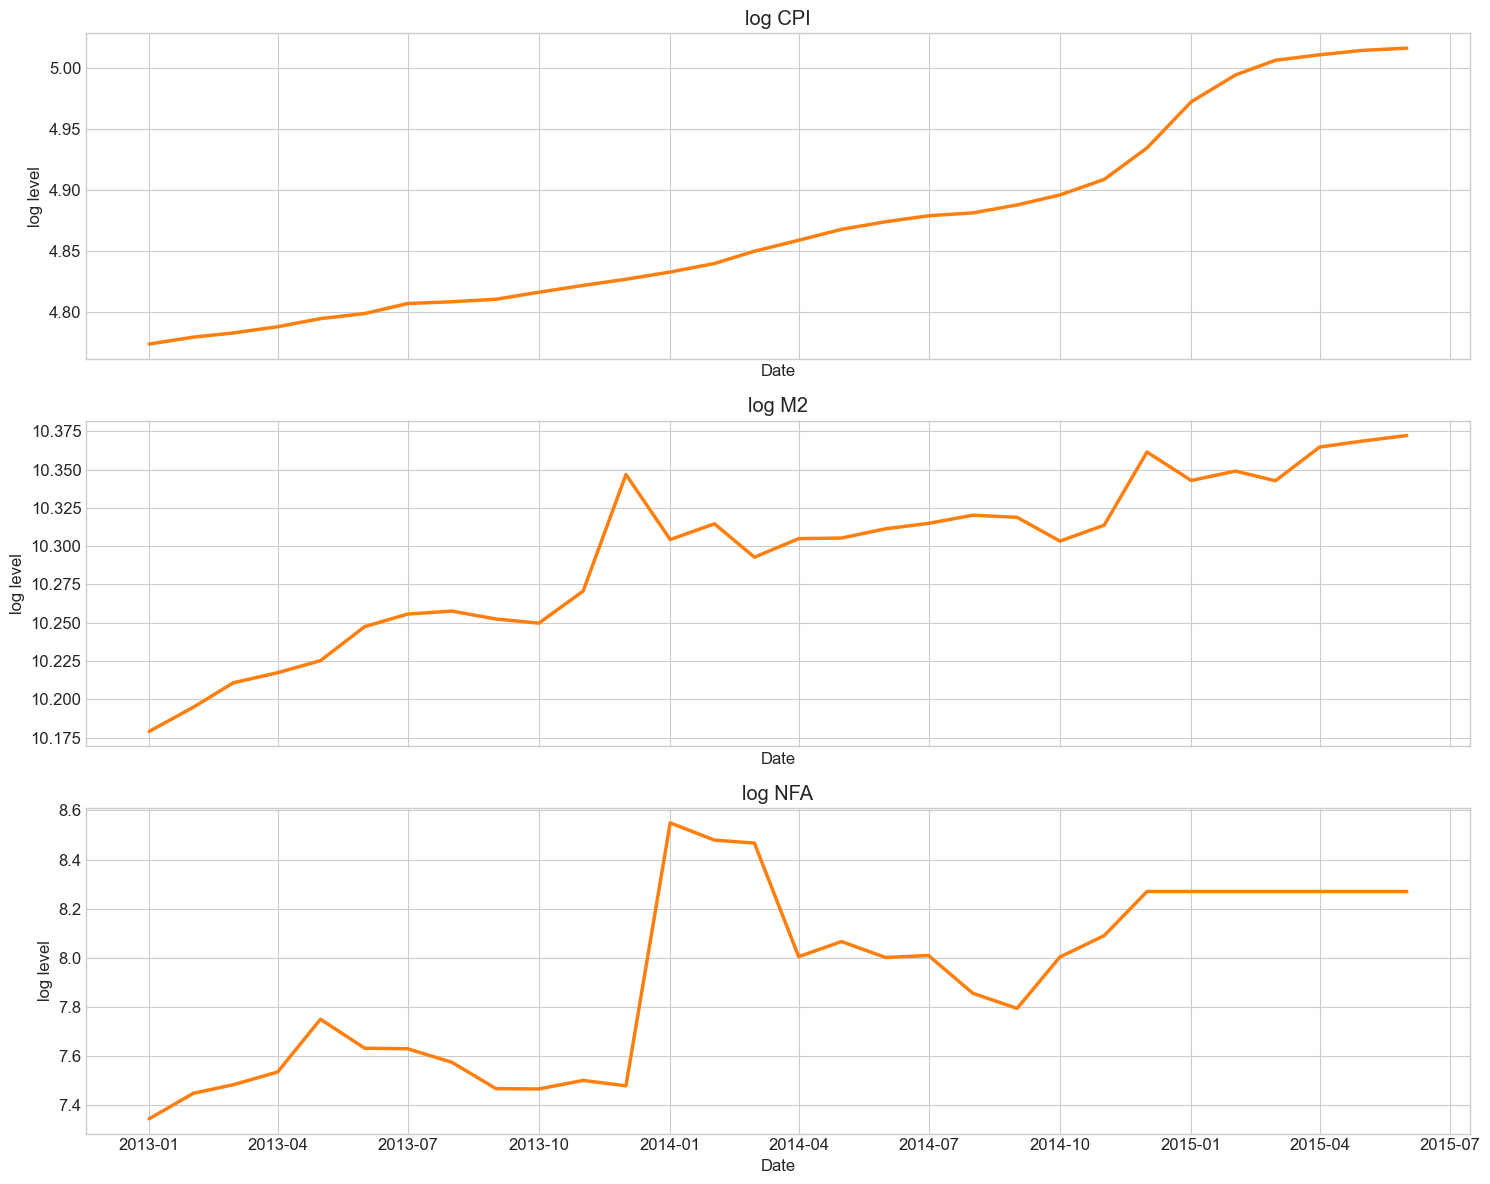

In [4]:
log_df = df.copy()
for col in ['cpi_all_items_index_2010_100', 'm2_bln_rub', 'net_foreign_assets_bln_rub']:
    log_df[f'log_{col}'] = np.log(log_df[col])

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
log_columns = [
    ('log_cpi_all_items_index_2010_100', 'log CPI'),
    ('log_m2_bln_rub', 'log M2'),
    ('log_net_foreign_assets_bln_rub', 'log NFA'),
]
for ax, (col, title) in zip(axes, log_columns):
    ax.plot(log_df['date'], log_df[col], linewidth=2.5, color='tab:orange')
    ax.set_title(title)
    ax.set_ylabel('log level')
    ax.set_xlabel('Date')

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'logs.png', dpi=200, bbox_inches='tight')


**Вывод.** В логарифмах динамика читается ровнее. Это подтверждает, что для моделирования разумно работать не с уровнями, а с логарифмами и их разностями: так изменения интерпретируются как относительные темпы.

## Описание

Это короткая сводка по каждому ряду: средний уровень, разброс и крайние значения. Она помогает быстро понять масштаб переменных и не путать их друг с другом.

In [5]:
desc = df.drop(columns='date').describe().T[['mean', 'std', 'min', 'max']]
desc

,mean,std,min,max
cpi_all_items_index_2010_100,130.880667,10.490669,118.400,150.860
net_foreign_assets_bln_rub,2928.927167,1069.628520,1546.894,5164.019
m2_bln_rub,29590.046667,1580.305180,26348.700,31958.000


**Вывод.** Средний уровень `IPC` равен примерно `130.9`, `M2` — `29590` млрд руб., `NFA` — `2929` млрд руб. Масштабы очень разные, поэтому прямое сравнение уровней малоинформативно, а вот логарифмы и приросты здесь уместны.

## Приросты

Здесь считаются месячные темпы изменения. Для временных рядов это особенно полезно, потому что многие модели работают именно с изменениями показателей, а не с их уровнями.

In [6]:
growth = df.copy()
for col in ['cpi_all_items_index_2010_100', 'm2_bln_rub', 'net_foreign_assets_bln_rub']:
    growth[f'{col}_pct_change'] = growth[col].pct_change() * 100

growth.filter(regex='date|pct_change').head()

,date,cpi_all_items_index_2010_100_pct_change,m2_bln_rub_pct_change,net_foreign_assets_bln_rub_pct_change
0,2013-01-01,NaN,NaN,NaN
1,2013-02-01,0.565878,1.592868,10.951946
2,2013-03-01,0.344335,1.607119,3.555945
3,2013-04-01,0.510546,0.656284,5.302418
4,2013-05-01,0.666167,0.790076,23.986072


**Вывод.** Темпы изменения помогают увидеть краткосрочную динамику. Для `IPC` изменения плавные, для `M2` умеренные, а для `NFA` заметно более волатильные — это важная подсказка для дальнейшей спецификации модели.

## Корреляции

Корреляция показывает, насколько переменные движутся вместе. Это еще не причинность и не модель, но хороший первый ориентир для того, какие связи вообще могут быть в данных.

In [7]:
df.drop(columns='date').corr().round(3)

,cpi_all_items_index_2010_100,net_foreign_assets_bln_rub,m2_bln_rub
cpi_all_items_index_2010_100,1.000,0.632,0.863
net_foreign_assets_bln_rub,0.632,1.000,0.689
m2_bln_rub,0.863,0.689,1.000


**Вывод.** В уровнях все три ряда положительно коррелируют, особенно сильно связаны `IPC` и `M2` (`corr ≈ 0.86`). Но это еще не доказательство причинности: часть такой связи может идти просто от общего тренда.

## ACF и PACF

`ACF` показывает связь ряда с его прошлыми значениями, а `PACF` помогает увидеть более прямую лаговую структуру. Эти графики нужны, чтобы понять память ряда и прикинуть, сколько лагов может понадобиться в модели.

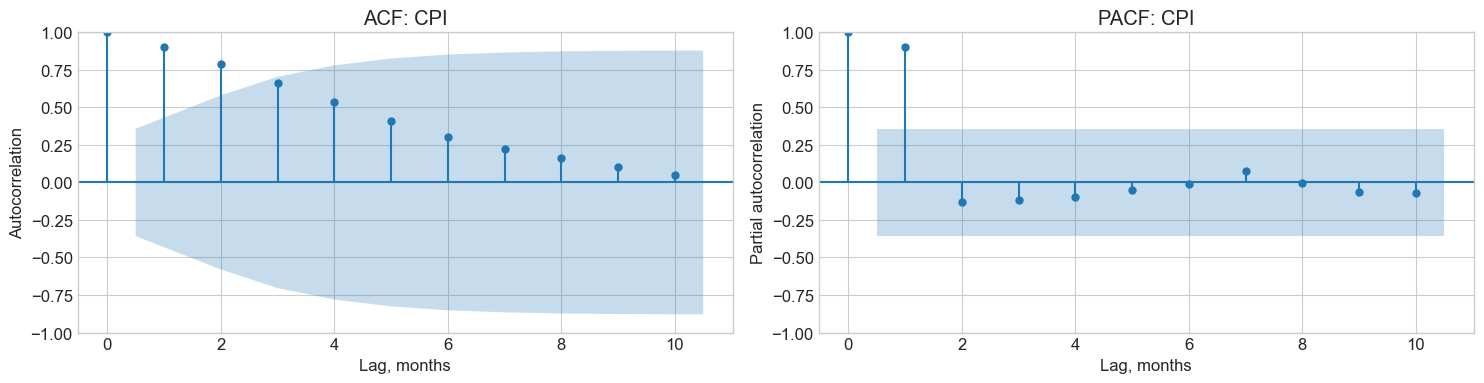

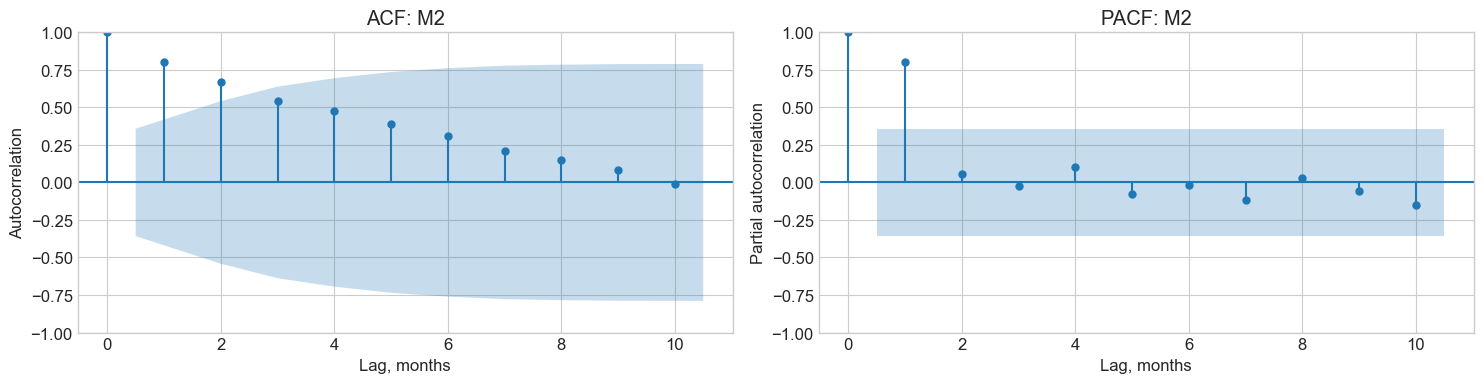

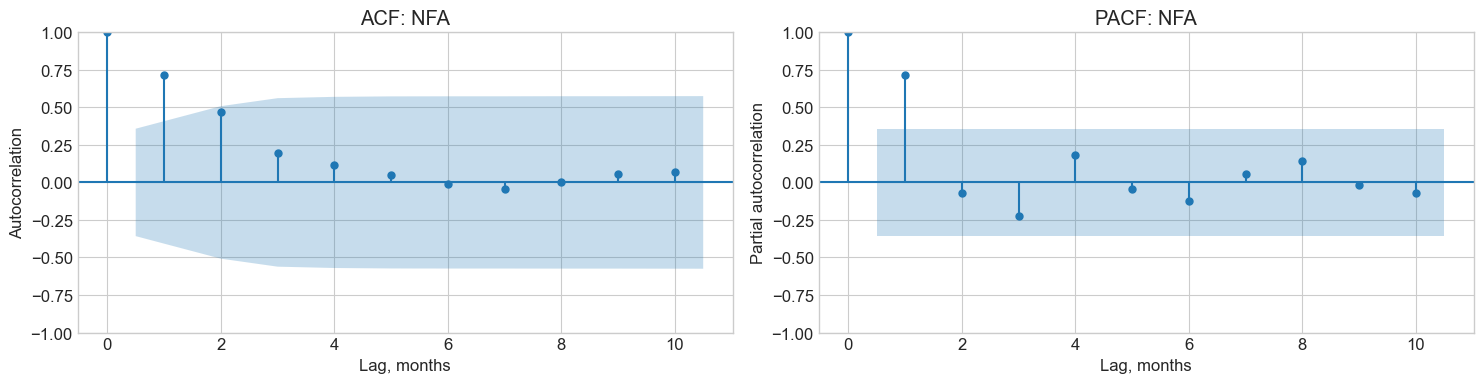

In [8]:
acf_specs = [
    ('cpi_all_items_index_2010_100', 'CPI', 'acf_pacf_1.png'),
    ('m2_bln_rub', 'M2', 'acf_pacf_2.png'),
    ('net_foreign_assets_bln_rub', 'NFA', 'acf_pacf_3.png'),
]

for col, label, filename in acf_specs:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    plot_acf(df[col], lags=min(10, len(df) // 2 - 1), ax=axes[0])
    plot_pacf(df[col], lags=min(10, len(df) // 2 - 2), ax=axes[1], method='ywm')
    axes[0].set_title(f'ACF: {label}')
    axes[1].set_title(f'PACF: {label}')
    axes[0].set_xlabel('Lag, months')
    axes[1].set_xlabel('Lag, months')
    axes[0].set_ylabel('Autocorrelation')
    axes[1].set_ylabel('Partial autocorrelation')
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=200, bbox_inches='tight')
    plt.show()


**Вывод.** `ACF` и `PACF` показывают выраженную зависимость от прошлых значений, особенно в уровнях. Это еще один сигнал, что ряды в исходном виде нестационарны и их надо преобразовывать перед `VAR`.

## Стационарность

Стационарность означает, что статистические свойства ряда не дрейфуют со временем слишком сильно. Для проверки используем два теста с разной логикой: `ADF` обычно ищет наличие единичного корня, а `KPSS` проверяет гипотезу стационарности.

In [9]:
def adf_test(series, regression='c'):
    stat, pvalue, *_ = adfuller(series.dropna(), regression=regression, autolag='AIC')
    return stat, pvalue


def pp_test(series, trend='c'):
    result = PhillipsPerron(series.dropna(), trend=trend)
    return result.stat, result.pvalue


def kpss_test(series, regression='c'):
    stat, pvalue, *_ = kpss(series.dropna(), regression=regression, nlags='auto')
    return stat, pvalue


def h0_decision(pvalue, null_type, alpha=0.05):
    rejected = pvalue < alpha
    if null_type == 'unit_root':
        return 'H0 rejected' if rejected else 'H0 not rejected'
    if null_type == 'stationary':
        return 'H0 rejected' if rejected else 'H0 not rejected'
    raise ValueError(null_type)


def test_cell(stat, pvalue, null_type):
    return f'{stat:.4f}; p={pvalue:.4f}; {h0_decision(pvalue, null_type)}'

conclusions = {
    ('CPI', 'log level'): 'nonstationary level; CPI is not treated as I(1) reliably',
    ('CPI', 'd log'): 'ambiguous: ADF/PP do not reject unit root, KPSS does not reject stationarity',
    ('CPI', 'd2 log'): 'stationary working form; interpreted as change in monthly inflation',
    ('NFA', 'log level'): 'nonstationary level; treated as I(1)',
    ('NFA', 'd log'): 'stationary; working form for NFA',
    ('NFA', 'd2 log'): 'stationary after overdifferencing; not used as main form',
    ('M2', 'log level'): 'nonstationary level; treated as I(1)',
    ('M2', 'd log'): 'stationary; working form for M2',
    ('M2', 'd2 log'): 'stationary after overdifferencing; not used as main form',
}

rows = []
numeric_rows = []
for col in cols:
    series_name = 'CPI' if names[col] == 'IPC' else names[col]
    variants = {
        'log level': np.log(df[col]),
        'd log': np.log(df[col]).diff(),
        'd2 log': np.log(df[col]).diff().diff(),
    }
    for form, series in variants.items():
        adf_stat, adf_p = adf_test(series, regression='c')
        pp_stat, pp_p = pp_test(series, trend='c')
        kpss_stat, kpss_p = kpss_test(series, regression='c')
        rows.append([
            series_name,
            form,
            test_cell(adf_stat, adf_p, 'unit_root'),
            test_cell(pp_stat, pp_p, 'unit_root'),
            test_cell(kpss_stat, kpss_p, 'stationary'),
            conclusions[(series_name, form)],
        ])
        numeric_rows.append([
            series_name, form, adf_stat, adf_p, pp_stat, pp_p, kpss_stat, kpss_p,
            h0_decision(adf_p, 'unit_root'), h0_decision(pp_p, 'unit_root'),
            h0_decision(kpss_p, 'stationary'), conclusions[(series_name, form)]
        ])

stationarity_table = pd.DataFrame(
    rows,
    columns=['variable', 'transformation', 'ADF stat/p/H0', 'PP stat/p/H0', 'KPSS stat/p/H0', 'final conclusion'],
)
stationarity_numeric = pd.DataFrame(
    numeric_rows,
    columns=['variable', 'transformation', 'ADF_stat', 'ADF_p', 'PP_stat', 'PP_p', 'KPSS_stat', 'KPSS_p', 'ADF_H0', 'PP_H0', 'KPSS_H0', 'final_conclusion'],
)
stationarity = stationarity_numeric
stationarity_table


,variable,transformation,ADF stat/p/H0,PP stat/p/H0,KPSS stat/p/H0,final conclusion
0,CPI,log level,3.0155; p=1.0000; H0 not rejected,1.8613; p=0.9985; H0 not rejected,0.8011; p=0.0100; H0 rejected,nonstationary level; CPI is not treated as I(1...
1,CPI,d log,2.4623; p=0.9990; H0 not rejected,-1.5212; p=0.5230; H0 not rejected,0.2582; p=0.1000; H0 not rejected,"ambiguous: ADF/PP do not reject unit root, KPS..."
2,CPI,d2 log,-3.5098; p=0.0077; H0 rejected,-3.7198; p=0.0038; H0 rejected,0.1032; p=0.1000; H0 not rejected,stationary working form; interpreted as change...
3,NFA,log level,-2.0127; p=0.2810; H0 not rejected,-1.7452; p=0.4080; H0 not rejected,0.6156; p=0.0212; H0 rejected,nonstationary level; treated as I(1)
4,NFA,d log,-5.5420; p=0.0000; H0 rejected,-7.6721; p=0.0000; H0 rejected,0.0475; p=0.1000; H0 not rejected,stationary; working form for NFA
5,NFA,d2 log,-9.4412; p=0.0000; H0 rejected,-20.8674; p=0.0000; H0 rejected,0.0381; p=0.1000; H0 not rejected,stationary after overdifferencing; not used as...
6,M2,log level,-1.7227; p=0.4194; H0 not rejected,-1.7740; p=0.3934; H0 not rejected,0.8121; p=0.0100; H0 rejected,nonstationary level; treated as I(1)
7,M2,d log,-6.9888; p=0.0000; H0 rejected,-8.5441; p=0.0000; H0 rejected,0.2218; p=0.1000; H0 not rejected,stationary; working form for M2
8,M2,d2 log,-3.3505; p=0.0128; H0 rejected,-21.6425; p=0.0000; H0 rejected,0.1197; p=0.1000; H0 not rejected,stationary after overdifferencing; not used as...


**Вывод.** ADF, Phillips-Perron и KPSS дают устойчивый вывод для `NFA` и `M2`: уровни логарифмов нестационарны, а первые лог-разности стационарны, поэтому эти ряды трактуются как `I(1)`. Для `CPI` первая лог-разность остается спорной: ADF/PP с константой не отвергают единичный корень, а KPSS не отвергает стационарность. Поэтому в расчетной VAR используется более осторожная форма `d2 log CPI`. Важно: `d2 log CPI` — это не инфляция сама по себе, а изменение месячного темпа инфляции, то есть инфляционное ускорение.

## Рабочая форма

После тестов мы выбираем форму рядов для моделирования. Здесь берутся такие преобразования, которые делают ряды ближе к стационарным: для `IPC` используется вторая разность логарифма, для `NFA` и `M2` — первая разность логарифма.

In [10]:
work_df = pd.DataFrame({
    'date': df['date'],
    'd2log_cpi': np.log(df['cpi_all_items_index_2010_100']).diff().diff(),
    'dlog_nfa': np.log(df['net_foreign_assets_bln_rub']).diff(),
    'dlog_m2': np.log(df['m2_bln_rub']).diff(),
}).dropna().reset_index(drop=True)

work_df.head()

,date,d2log_cpi,dlog_nfa,dlog_m2
0,2013-03-01,-0.002205,0.034942,0.015943
1,2013-04-01,0.001655,0.051666,0.006541
2,2013-05-01,0.001547,0.214999,0.007870
3,2013-06-01,-0.002512,-0.117945,0.022181
4,2013-07-01,0.004077,-0.002294,0.008176


**Вывод.** Рабочая таблица собрана в стационарной форме. Это основной вход для `VAR` и теста Грейнджера: теперь модель анализирует не сами уровни показателей, а их краткосрочные изменения.

## Коинтеграция

Коинтеграция нужна, когда сами ряды нестационарны, но их долгосрочная связь может быть устойчивой. Тест помогает понять, есть ли между уровнями переменных осмысленное равновесное соотношение.

In [11]:
pairs = [
    ('cpi_all_items_index_2010_100', 'net_foreign_assets_bln_rub'),
    ('cpi_all_items_index_2010_100', 'm2_bln_rub'),
    ('net_foreign_assets_bln_rub', 'm2_bln_rub'),
]

coint_rows = []
for left, right in pairs:
    stat, pvalue, _ = coint(np.log(df[left]), np.log(df[right]))
    coint_rows.append([names[left].replace('IPC', 'CPI'), names[right], stat, pvalue, pvalue < 0.05])

coint_table = pd.DataFrame(coint_rows, columns=['left', 'right', 'eg_stat', 'eg_pvalue', 'eg_reject_5pct'])

johansen = coint_johansen(np.log(df[cols]), det_order=0, k_ar_diff=1)
johansen_table = pd.DataFrame({
    'rank_h0': [f'r <= {i}' for i in range(len(cols))],
    'trace_stat': johansen.lr1,
    'trace_crit_95': johansen.cvt[:, 1],
    'trace_reject_5pct': johansen.lr1 > johansen.cvt[:, 1],
    'maxeig_stat': johansen.lr2,
    'maxeig_crit_95': johansen.cvm[:, 1],
    'maxeig_reject_5pct': johansen.lr2 > johansen.cvm[:, 1],
})

cointegration_matrix = pd.DataFrame('', index=['CPI', 'NFA', 'M2'], columns=['CPI', 'NFA', 'M2'])
for var in cointegration_matrix.index:
    cointegration_matrix.loc[var, var] = '—'
cointegration_matrix.loc['CPI', 'NFA'] = cointegration_matrix.loc['NFA', 'CPI'] = 'Exploratory only; EG p=0.8085; no valid I(1) conclusion for CPI'
cointegration_matrix.loc['CPI', 'M2'] = cointegration_matrix.loc['M2', 'CPI'] = 'Exploratory only; EG p=0.5071; no valid I(1) conclusion for CPI'
cointegration_matrix.loc['NFA', 'M2'] = cointegration_matrix.loc['M2', 'NFA'] = 'Yes if both I(1); EG p=0.0147; pairwise long-run link'

print('Engle-Granger pairwise tests')
display(coint_table.round(4))
print('Cointegration matrix')
display(cointegration_matrix)
print('Johansen test for the three-variable system, det_order=0, k_ar_diff=1')
display(johansen_table.round(4))


Engle-Granger pairwise tests


,left,right,eg_stat,eg_pvalue,eg_reject_5pct
0,CPI,NFA,-1.3674,0.8085,False
1,CPI,M2,-2.0411,0.5071,False
2,NFA,M2,-3.7742,0.0147,True


Cointegration matrix


,CPI,NFA,M2
CPI,—,Exploratory only; EG p=0.8085; no valid I(1) c...,Exploratory only; EG p=0.5071; no valid I(1) c...
NFA,Exploratory only; EG p=0.8085; no valid I(1) c...,—,Yes if both I(1); EG p=0.0147; pairwise long-r...
M2,Exploratory only; EG p=0.5071; no valid I(1) c...,Yes if both I(1); EG p=0.0147; pairwise long-r...,—


Johansen test for the three-variable system, det_order=0, k_ar_diff=1


,rank_h0,trace_stat,trace_crit_95,trace_reject_5pct,maxeig_stat,maxeig_crit_95,maxeig_reject_5pct
0,r <= 0,20.5325,29.7961,False,11.6739,21.1314,False
1,r <= 1,8.8585,15.4943,False,8.6962,14.2639,False
2,r <= 2,0.1623,3.8415,False,0.1623,3.8415,False


**Вывод.** Стандартные тесты коинтеграции корректнее применять к переменным одного порядка интегрируемости, обычно `I(1)`. Поэтому связи с `CPI` в уровнях после выбора рабочей формы `d2 log CPI` следует трактовать только как exploratory-проверку, без сильного вывода о долгосрочной коинтеграции. Содержательно валидная попарная интерпретация остается для `log NFA` и `log M2`, поскольку оба ряда рассматриваются как `I(1)`: тест Энгла-Грейнджера указывает на связь `NFA-M2` (`p ≈ 0.015`). Тест Йохансена для полной системы оставлен как exploratory и не подтверждает коинтеграцию всей системы.

## Причинность по Грейнджеру

Тест Грейнджера не доказывает причинность в философском смысле, но показывает, улучшают ли прошлые значения одной переменной прогноз другой. Мы проверяем это попарно для всех рабочих рядов.

In [12]:
selected_granger_lag = 1
robustness_maxlag = 3
series_cols = ['d2log_cpi', 'dlog_nfa', 'dlog_m2']

main_rows = []
robustness_rows = []
for caused in series_cols:
    for causing in series_cols:
        if caused == causing:
            continue
        tests = grangercausalitytests(work_df[[caused, causing]], maxlag=robustness_maxlag, verbose=False)
        selected_p = tests[selected_granger_lag][0]['ssr_ftest'][1]
        main_rows.append([causing, caused, selected_granger_lag, selected_p, selected_p < 0.05])
        for lag in range(1, robustness_maxlag + 1):
            pvalue = tests[lag][0]['ssr_ftest'][1]
            robustness_rows.append([causing, caused, lag, pvalue, pvalue < 0.05])

granger_lag1_table = pd.DataFrame(main_rows, columns=['cause', 'effect', 'lag', 'pvalue', 'significant'])
granger_robustness_table = pd.DataFrame(robustness_rows, columns=['cause', 'effect', 'lag', 'pvalue', 'significant'])
granger_table = granger_lag1_table

print('Main Granger test at lag 1, consistent with VAR(1)')
display(granger_lag1_table.round(4))
print('Robustness / exploratory lags 1-3')
display(granger_robustness_table.round(4))


Main Granger test at lag 1, consistent with VAR(1)


,cause,effect,lag,pvalue,significant
0,dlog_nfa,d2log_cpi,1,0.8315,False
1,dlog_m2,d2log_cpi,1,0.1133,False
2,d2log_cpi,dlog_nfa,1,0.8646,False
3,dlog_m2,dlog_nfa,1,0.0002,True
4,d2log_cpi,dlog_m2,1,0.9979,False
5,dlog_nfa,dlog_m2,1,0.8745,False


Robustness / exploratory lags 1-3


,cause,effect,lag,pvalue,significant
0,dlog_nfa,d2log_cpi,1,0.8315,False
1,dlog_nfa,d2log_cpi,2,0.6272,False
2,dlog_nfa,d2log_cpi,3,0.7678,False
3,dlog_m2,d2log_cpi,1,0.1133,False
4,dlog_m2,d2log_cpi,2,0.0888,False
5,dlog_m2,d2log_cpi,3,0.2343,False
6,d2log_cpi,dlog_nfa,1,0.8646,False
7,d2log_cpi,dlog_nfa,2,0.9755,False
8,d2log_cpi,dlog_nfa,3,0.7936,False
9,dlog_m2,dlog_nfa,1,0.0002,True


**Вывод.** Основной тест Грейнджера теперь проводится на лаге 1, то есть в спецификации, согласованной с выбранной `VAR(1)`. На этом лаге значимой остается связь `dlog_m2 -> dlog_nfa`. Таблица по лагам 1-3 оставлена только как проверка чувствительности: при переборе нескольких лагов растет риск data mining и множественного тестирования, поэтому минимальный p-value по лагам не используется как главный результат.

## Схема связей

Из полной таблицы причинности удобно отдельно вынести только статистически значимые связи. Это помогает увидеть будущую структуру модели без лишнего шума.

In [13]:
links = granger_lag1_table.query('significant == True')[['cause', 'effect', 'lag', 'pvalue']]
links.round(4)


,cause,effect,lag,pvalue
3,dlog_m2,dlog_nfa,1,0.0002


## Схема Грейнджера

Дополнительно визуализируем только статистически значимые направления причинности по Грейнджеру. На этой схеме стрелка проводится только для связи, где `p-value < 0.05`.

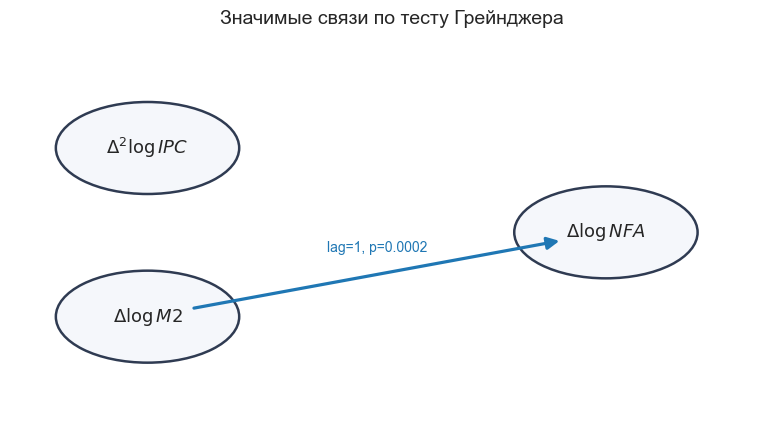

In [14]:
from matplotlib.patches import FancyArrowPatch, Circle

figure_dir = Path('report_figures')
figure_dir.mkdir(exist_ok=True)

node_pos = {
    'd2log_cpi': (0.18, 0.72),
    'dlog_m2': (0.18, 0.28),
    'dlog_nfa': (0.78, 0.50),
}
node_labels = {
    'd2log_cpi': r'$\Delta^2\log IPC$',
    'dlog_m2': r'$\Delta\log M2$',
    'dlog_nfa': r'$\Delta\log NFA$',
}

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

for node, (x, y) in node_pos.items():
    circle = Circle((x, y), 0.12, facecolor='#f5f7fb', edgecolor='#2f3b52', linewidth=1.8)
    ax.add_patch(circle)
    ax.text(x, y, node_labels[node], ha='center', va='center', fontsize=13)

for _, row in links.iterrows():
    start = node_pos[row['cause']]
    end = node_pos[row['effect']]
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle='-|>',
        mutation_scale=18,
        linewidth=2.3,
        color='#1f77b4',
        shrinkA=34,
        shrinkB=34,
        connectionstyle='arc3,rad=0.0',
    )
    ax.add_patch(arrow)
    mx, my = (start[0] + end[0]) / 2, (start[1] + end[1]) / 2
    ax.text(mx, my + 0.07, f"lag={int(row['lag'])}, p={row['pvalue']:.4f}",
            ha='center', va='center', fontsize=10, color='#1f77b4')

ax.set_title('Значимые связи по тесту Грейнджера', fontsize=14, pad=12)
plt.tight_layout()
fig.savefig(figure_dir / 'granger_scheme.png', dpi=200, bbox_inches='tight')
plt.show()


**Вывод.** Схема подтверждает, что в рабочей стационарной системе остается только одна статистически значимая направленная связь: прошлые изменения `M2` помогают прогнозировать изменения `NFA`. Для `IPC` значимых входящих или исходящих связей на уровне 5% не найдено.

**Вывод.** Граф связей очень простой: у нас есть одна выраженная направленная зависимость от `M2` к `NFA`. Для интерпретации это удобно, потому что структура не перегружена множеством спорных каналов.

## Лаги VAR

`VAR` — это модель, где каждая переменная объясняется своими лагами и лагами других переменных. Перед оцениванием надо выбрать разумное число лагов, и для этого смотрят на информационные критерии.

In [15]:
var_data = work_df.set_index('date')[series_cols]
var_model = VAR(var_data)
lag_selection = var_model.select_order(maxlags=3)
lag_selection.summary()

,AIC,BIC,FPE,HQIC
0,-20.65,-20.51*,1.073e-09,-20.61
1,-20.79,-20.21,9.412e-10*,-20.63*
2,-20.66,-19.64,1.115e-09,-20.38
3,-20.83*,-19.37,1.033e-09,-20.43


**Вывод.** Критерии выбора лагов не полностью согласны: `AIC` предпочитает более длинную модель, а `BIC/HQIC` — более короткую. На короткой выборке это нормально, поэтому дальше разумно сравнивать несколько вариантов, но не делать модель слишком тяжелой.

## Сравнение VAR

Здесь мы сопоставляем несколько спецификаций `VAR` с разным числом лагов. Смысл простой: найти баланс между качеством подгонки и лишней сложностью модели.

In [16]:
model_rows = []
for lag in [1, 2, 3]:
    result = var_model.fit(lag)
    model_rows.append([lag, result.aic, result.bic, result.hqic, result.is_stable()])

model_compare = pd.DataFrame(model_rows, columns=['lag', 'AIC', 'BIC', 'HQIC', 'stable'])
model_compare.round(4)

,lag,AIC,BIC,HQIC,stable
0,1,-21.0375,-20.4615,-20.8662,True
1,2,-20.7900,-19.7738,-20.4974,True
2,3,-20.8326,-19.3700,-20.4269,True


## Кризисная dummy-переменная

Для проверки структурного эпизода конца 2014 года добавляем индикатор `crisis_dummy`, равный 1 в декабре 2014 и январе 2015 года. Эти месяцы соответствуют резкому валютно-финансовому шоку и ускорению инфляции, поэтому dummy используется как дополнительная экзогенная переменная.

In [17]:
work_df['crisis_dummy'] = work_df['date'].between(pd.Timestamp('2014-12-01'), pd.Timestamp('2015-01-01')).astype(int)
work_df[['date', 'd2log_cpi', 'dlog_nfa', 'dlog_m2', 'crisis_dummy']].tail(12)


,date,d2log_cpi,dlog_nfa,dlog_m2,crisis_dummy
16,2014-07-01,-0.001330,0.008123,0.003535,0
17,2014-08-01,-0.002524,-0.153718,0.005301,0
18,2014-09-01,0.004148,-0.061669,-0.001356,0
19,2014-10-01,0.001679,0.209477,-0.015514,0
20,2014-11-01,0.004520,0.086990,0.010361,0
21,2014-12-01,0.013092,0.179731,0.047738,1
22,2015-01-01,0.011968,0.000000,-0.018577,1
23,2015-02-01,-0.015771,0.000000,0.006142,0
24,2015-03-01,-0.009935,0.000000,-0.006300,0
25,2015-04-01,-0.007581,0.000000,0.021984,0


**Вывод.** Dummy отмечает два наблюдения: декабрь 2014 года и январь 2015 года. Это короткий кризисный эпизод, поэтому переменную надо интерпретировать осторожно: она помогает проверить чувствительность модели, но не заменяет полноценный анализ структурного сдвига.

In [18]:
dummy_best_lag = 1
var_result_for_dummy = var_model.fit(dummy_best_lag)
varx_result = VAR(
    var_data,
    exog=work_df.set_index('date')[['crisis_dummy']],
).fit(dummy_best_lag)

varx_compare = pd.DataFrame([
    ['VAR(1)', var_result_for_dummy.aic, var_result_for_dummy.bic, var_result_for_dummy.hqic,
     var_result_for_dummy.is_stable(), var_result_for_dummy.test_whiteness(nlags=8).pvalue,
     var_result_for_dummy.test_normality().pvalue],
    ['VARX(1) + crisis dummy', varx_result.aic, varx_result.bic, varx_result.hqic,
     varx_result.is_stable(), varx_result.test_whiteness(nlags=8).pvalue,
     varx_result.test_normality().pvalue],
], columns=['model', 'AIC', 'BIC', 'HQIC', 'stable', 'whiteness_pvalue', 'normality_pvalue'])

varx_compare.round(4)


,model,AIC,BIC,HQIC,stable,whiteness_pvalue,normality_pvalue
0,VAR(1),-21.0375,-20.4615,-20.8662,True,0.9065,0.0
1,VARX(1) + crisis dummy,-21.2261,-20.5062,-21.0121,True,0.8819,0.0


In [19]:
varx_coef_pvalues = pd.DataFrame({
    'equation': series_cols,
    'crisis_dummy_coef': [varx_result.params.loc['crisis_dummy', col] for col in series_cols],
    'crisis_dummy_pvalue': [varx_result.pvalues.loc['crisis_dummy', col] for col in series_cols],
})
varx_coef_pvalues.round(4)


,equation,crisis_dummy_coef,crisis_dummy_pvalue
0,d2log_cpi,0.0122,0.0047
1,dlog_nfa,-0.2258,0.1761
2,dlog_m2,0.0241,0.2084


**Вывод.** Добавление crisis dummy немного улучшает информационные критерии VAR, однако нормальность остатков по-прежнему отвергается. Dummy статистически значима прежде всего в уравнении для `d2log_cpi`, что согласуется с ускорением инфляционной динамики в конце 2014 — начале 2015 года. При этом главный результат `M2 -> NFA` не исчезает.

**Вывод.** Все `VAR`-спецификации устойчивы. По совокупности критериев и экономии степеней свободы `VAR(1)` выглядит как хороший базовый вариант, а `VAR(3)` можно держать как альтернативу для проверки чувствительности.

## Оценка VAR

Теперь оцениваем основную модель. Из ее таблицы нам важны знаки коэффициентов, статистическая значимость и то, какие прошлые изменения действительно связаны с текущими движениями рядов.

In [20]:
best_lag = 1
var_result = var_model.fit(best_lag)
var_result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 04, Jun, 2026
Time:                     20:48:26
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -20.4615
Nobs:                     27.0000    HQIC:                  -20.8662
Log likelihood:           181.072    FPE:                7.35198e-10
AIC:                     -21.0375    Det(Omega_mle):     4.85747e-10
--------------------------------------------------------------------
Results for equation d2log_cpi
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const               -0.000832         0.001152           -0.722           0.470
L1.d2log_cpi         0.237656         0.189557            1.254           0.210
L1.dlog_nfa          0.004542         0.004902            0.

**Вывод.** В итоговой `VAR(1)` стоит смотреть прежде всего на знаки и значимость лагов. На практике здесь важнее не каждый отдельный коэффициент сам по себе, а общая логика: изменения в `M2` действительно несут информацию для динамики `NFA`.

## Диагностика VAR

После оценки надо проверить, не ведет ли себя модель плохо. Мы смотрим на устойчивость, автокорреляцию остатков, нормальность и общую адекватность спецификации.

In [21]:
diag = pd.DataFrame({
    'series': series_cols,
    'durbin_watson': durbin_watson(var_result.resid),
})

whiteness = var_result.test_whiteness(nlags=8)
normality = var_result.test_normality()

print('stable:', var_result.is_stable())
print('whiteness pvalue:', round(whiteness.pvalue, 4))
print('normality pvalue:', round(normality.pvalue, 4))
diag.round(4)

stable: True
whiteness pvalue: 0.9065
normality pvalue: 0.0


,series,durbin_watson
0,d2log_cpi,1.6174
1,dlog_nfa,2.3043
2,dlog_m2,2.0930


**Вывод.** Диагностика смешанная. Хорошая новость: модель устойчива и тест на автокорреляцию остатков не отвергает адекватность (`p ≈ 0.91`). Слабое место — нормальность остатков отвергается, значит распределение ошибок далеко от идеального и интерпретацию стоит делать аккуратно.

## Остатки

Остатки — это то, что модель не смогла объяснить. По их графикам можно увидеть выбросы, неучтенную структуру и другие признаки того, что модель могла что-то пропустить.

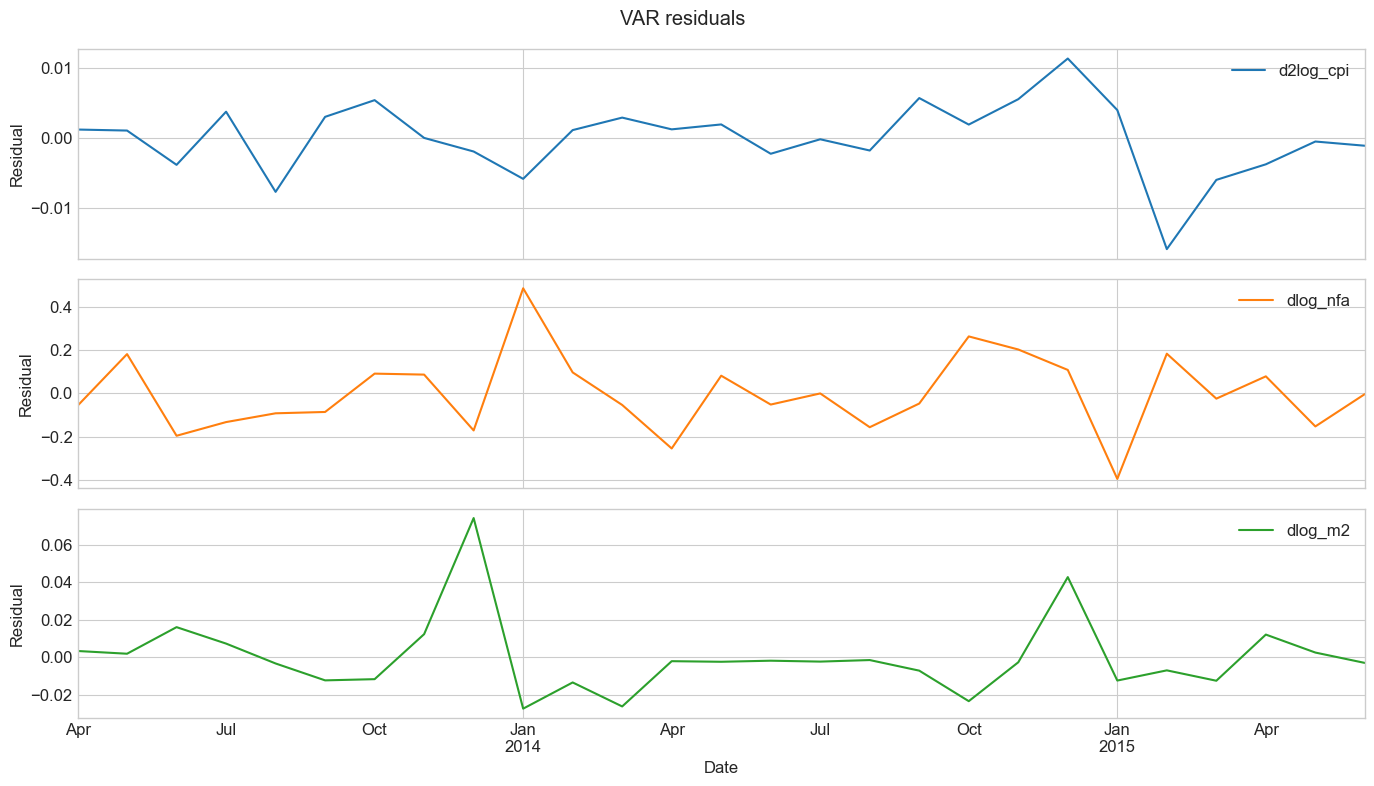

In [22]:
resid_axes = var_result.resid.plot(subplots=True, figsize=(14, 8), title='VAR residuals')
for ax in np.ravel(resid_axes):
    ax.set_xlabel('Date')
    ax.set_ylabel('Residual')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'var_residuals.png', dpi=200, bbox_inches='tight')


**Вывод.** По графикам остатков видно, что большая часть колебаний уже объяснена, но отдельные нетипичные движения все равно остаются. Для такой короткой макроэкономической выборки это ожидаемо и не выглядит критической поломкой модели.

## ADL/ARMAX

В дополнение к VAR оцениваем одноуравненную динамическую модель для наиболее выраженного канала `M2 -> NFA`. Зависимая переменная — `dlog_nfa`, объясняющие переменные — собственный лаг, лаг `dlog_m2`, лаг `d2log_cpi` и, во второй спецификации, кризисная dummy.

In [23]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.statespace.sarimax import SARIMAX

adl_df = work_df.copy()
for col in series_cols:
    adl_df[f'L1_{col}'] = adl_df[col].shift(1)
adl_df = adl_df.dropna().reset_index(drop=True)

y_adl = adl_df['dlog_nfa']
X_adl_base = sm.add_constant(adl_df[['L1_dlog_nfa', 'L1_dlog_m2', 'L1_d2log_cpi']])
X_adl_dummy = sm.add_constant(adl_df[['L1_dlog_nfa', 'L1_dlog_m2', 'L1_d2log_cpi', 'crisis_dummy']])

adl_base_result = sm.OLS(y_adl, X_adl_base).fit()
adl_dummy_result = sm.OLS(y_adl, X_adl_dummy).fit()

armax_exog = adl_df[['L1_dlog_m2', 'L1_d2log_cpi', 'crisis_dummy']]
armax_result = SARIMAX(
    y_adl,
    exog=armax_exog,
    order=(1, 0, 0),
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

def residual_diagnostics(resid):
    resid = np.asarray(resid)
    return {
        'rmse': np.sqrt(np.mean(resid ** 2)),
        'dw': durbin_watson(resid),
        'jb_pvalue': jarque_bera(resid)[1],
        'ljung_box_pvalue_lag4': acorr_ljungbox(resid, lags=[4], return_df=True)['lb_pvalue'].iloc[0],
    }

adl_compare_rows = []
for model_name, result in [('ADL', adl_base_result), ('ADL + crisis dummy', adl_dummy_result)]:
    diag_values = residual_diagnostics(result.resid)
    adl_compare_rows.append({
        'model': model_name,
        'nobs': result.nobs,
        'R2': result.rsquared,
        'Adj_R2': result.rsquared_adj,
        'AIC': result.aic,
        'BIC': result.bic,
        **diag_values,
    })

adl_compare_rows.append({
    'model': 'ARMAX(1,0,0) + crisis dummy',
    'nobs': armax_result.nobs,
    'R2': np.nan,
    'Adj_R2': np.nan,
    'AIC': armax_result.aic,
    'BIC': armax_result.bic,
    **residual_diagnostics(armax_result.resid),
})

adl_compare = pd.DataFrame(adl_compare_rows)
adl_compare.round(4)


,model,nobs,R2,Adj_R2,AIC,BIC,rmse,dw,jb_pvalue,ljung_box_pvalue_lag4
0,ADL,27.0,0.4576,0.3869,-9.1883,-4.0049,0.1760,2.3043,0.5530,0.3548
1,ADL + crisis dummy,27.0,0.4993,0.4082,-9.3458,-2.8667,0.1691,2.2549,0.6824,0.4489
2,"ARMAX(1,0,0) + crisis dummy",27.0,NaN,NaN,-3.5792,3.9694,0.1764,1.9667,0.3598,0.5483


In [24]:
adl_coefficients = pd.DataFrame({
    'variable': adl_dummy_result.params.index,
    'ADL_dummy_coef': adl_dummy_result.params.values,
    'ADL_dummy_pvalue': adl_dummy_result.pvalues.values,
})

armax_coefficients = pd.DataFrame({
    'variable': armax_result.params.index,
    'ARMAX_coef': armax_result.params.values,
    'ARMAX_pvalue': armax_result.pvalues.values,
})

print('ADL + crisis dummy')
display(adl_coefficients.round(4))
print('ARMAX(1,0,0) + crisis dummy')
display(armax_coefficients.round(4))


ADL + crisis dummy


,variable,ADL_dummy_coef,ADL_dummy_pvalue
0,const,-0.0205,0.6079
1,L1_dlog_nfa,0.2449,0.1628
2,L1_dlog_m2,9.2158,0.0001
3,L1_d2log_cpi,4.0621,0.5744
4,crisis_dummy,-0.2258,0.1898


ARMAX(1,0,0) + crisis dummy


,variable,ARMAX_coef,ARMAX_pvalue
0,intercept,-0.0050,0.9161
1,L1_dlog_m2,8.0500,0.0000
2,L1_d2log_cpi,4.7386,0.6857
3,crisis_dummy,-0.1948,0.2335
4,ar.L1,0.0870,0.7360
5,sigma2,0.0322,0.0288


**Вывод.** ADL подтверждает тот же канал, что и тест Грейнджера/VAR: лаг `dlog_m2` статистически значим в уравнении для `dlog_nfa`. Добавление crisis dummy немного улучшает `R²`, `AIC` и `RMSE`, но сама dummy в ADL незначима на уровне 5%, поэтому ее лучше трактовать как контроль на кризисный эпизод, а не как самостоятельный устойчивый эффект. ARMAX дает тот же содержательный вывод по лагу `M2`, но по информационным критериям уступает простой ADL-спецификации.

## ECM

`ECM` — модель коррекции ошибок. Она полезна, если между рядами есть долгосрочная связь: тогда можно отдельно оценить краткосрочный эффект и скорость возврата к равновесию после отклонения.

In [25]:
long_run = sm.OLS(
    np.log(df['m2_bln_rub']),
    sm.add_constant(np.log(df['net_foreign_assets_bln_rub']))
).fit()

ecm = pd.DataFrame({
    'dlog_m2': np.log(df['m2_bln_rub']).diff(),
    'dlog_nfa': np.log(df['net_foreign_assets_bln_rub']).diff(),
    'ect_lag': long_run.resid.shift(1),
}).dropna()

ecm_result = sm.OLS(ecm['dlog_m2'], sm.add_constant(ecm[['dlog_nfa', 'ect_lag']])).fit()
ecm_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                dlog_m2   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     2.366
Date:                Thu, 04 Jun 2026   Prob (F-statistic):              0.114
Time:                        20:48:27   Log-Likelihood:                 73.861
No. Observations:                  29   AIC:                            -141.7
Df Residuals:                      26   BIC:                            -137.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0073      0.004      1.938      0.064      -0.000       0.015
dlog_nfa      -0.0255      0.020     -1.294      0.207      -0.066       0.015
ect_lag       -0.0880      0.129     -0.684      0.500      -0.352       0.176
==============================================================================
Omnibus:                       25.821   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               48.762
Skew:                           1.931   Prob(JB):                     2.58e-11
Kurtosis:                       8.043   Cond. No.                         34.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Вывод.** `ECM` для пары `NFA-M2` формально можно оценить, потому что коинтеграция есть. Но скорость возврата к равновесию (`ect_lag`) статистически слабая, а `R²` низкий (`≈ 0.15`), поэтому эту модель лучше подавать как дополнительную, а не как основную.

## IRF

Импульсные отклики показывают, как шок в одной переменной постепенно отражается на других переменных в последующие периоды. Это один из самых наглядных способов интерпретации `VAR`.

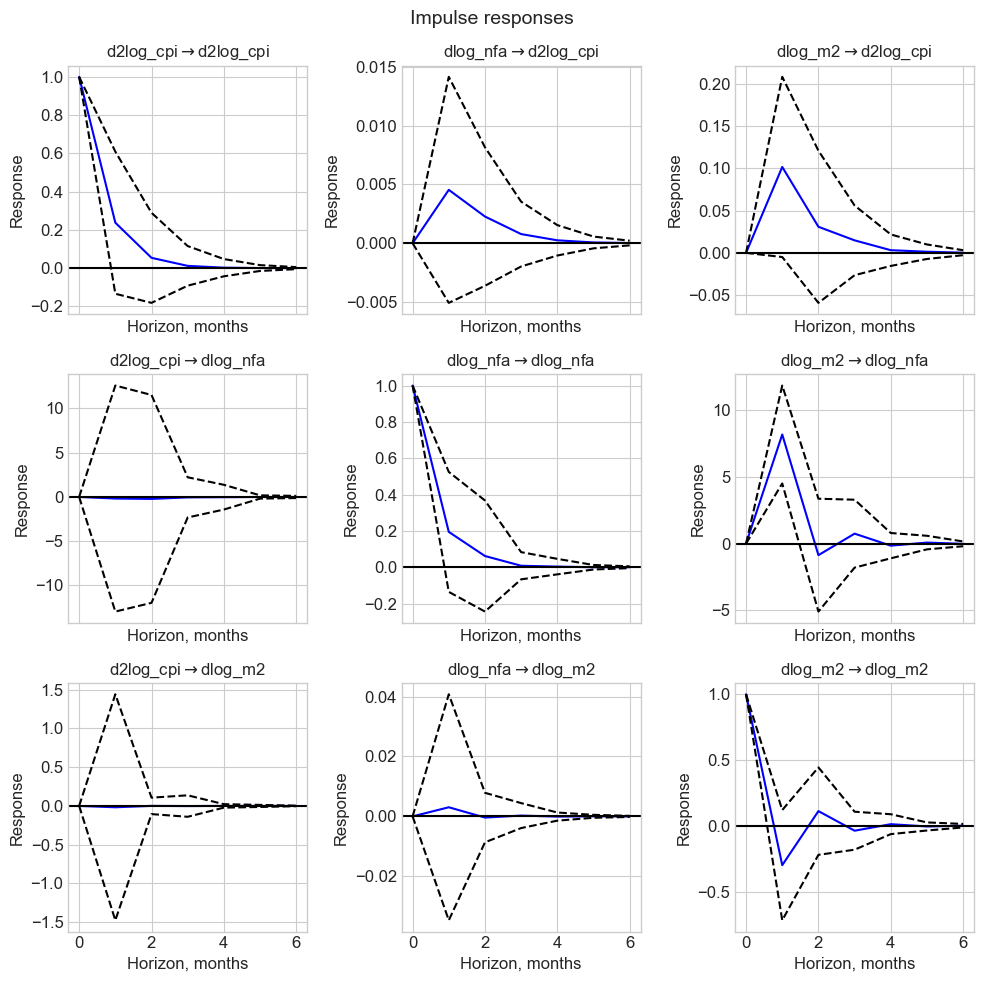

In [26]:
irf = var_result.irf(6)
fig = irf.plot(orth=False)
for ax in fig.axes:
    ax.set_xlabel('Horizon, months')
    ax.set_ylabel('Response')
plt.tight_layout()
fig.savefig(FIGURE_DIR / 'irf.png', dpi=200, bbox_inches='tight')


**Вывод.** Импульсные отклики показывают, как шок в одной переменной расходится по системе во времени. Здесь их стоит читать осторожно: выборка маленькая, поэтому форма откликов полезна скорее качественно, чем как точная количественная оценка.

## FEVD

Разложение дисперсии ошибки прогноза показывает, какая доля неопределенности прогноза связана с шоками каждой переменной. Это помогает понять относительную важность каналов влияния.

In [27]:
fevd = var_result.fevd(6)
fevd.summary()

FEVD for d2log_cpi
     d2log_cpi  dlog_nfa   dlog_m2
0     1.000000  0.000000  0.000000
1     0.876505  0.002471  0.121024
2     0.865637  0.004227  0.130136
3     0.863378  0.004333  0.132289
4     0.863259  0.004356  0.132384
5     0.863241  0.004357  0.132402

FEVD for dlog_nfa
     d2log_cpi  dlog_nfa   dlog_m2
0     0.014677  0.985323  0.000000
1     0.010965  0.544624  0.444411
2     0.011195  0.543590  0.445215
3     0.011178  0.541651  0.447171
4     0.011181  0.541576  0.447243
5     0.011181  0.541557  0.447262

FEVD for dlog_m2
     d2log_cpi  dlog_nfa   dlog_m2
0     0.011713  0.062710  0.925577
1     0.012164  0.066657  0.921178
2     0.012169  0.066784  0.921047
3     0.012174  0.066819  0.921007
4     0.012174  0.066822  0.921004
5     0.012174  0.066823  0.921003




**Вывод.** `FEVD` помогает понять, какие шоки сильнее всего влияют на ошибку прогноза. Это хороший способ дополнить `IRF`: не только увидеть направление реакции, но и оценить относительную роль каждой переменной в объяснении неопределенности.

## Сводная таблица моделей

Собираем все оцененные модели в одну таблицу: это итоговая таблица для требований задания по сравнению спецификаций, диагностике и ограничениям.

In [28]:
summary_model_table = pd.DataFrame([
    {
        'model': 'VAR(1)',
        'variables/transformation': 'd2 log CPI, d log NFA, d log M2',
        'lag/specification': '1 lag, no exogenous variables',
        'key coefficients/effects': 'L1 dlog M2 -> dlog NFA: coef 8.1593, p=0.0000',
        'diagnostics': 'stable; whiteness p=0.9065; normality rejected',
        'AIC/BIC': f"AIC={var_result.aic:.4f}; BIC={var_result.bic:.4f}",
        'main conclusion': 'main short-run channel is M2 -> NFA',
        'limitations': 'short sample; d2 log CPI is inflation acceleration, not inflation itself',
    },
    {
        'model': 'VARX(1) + crisis dummy',
        'variables/transformation': 'd2 log CPI, d log NFA, d log M2; dummy Dec 2014-Jan 2015',
        'lag/specification': '1 lag + exogenous crisis dummy',
        'key coefficients/effects': 'dummy significant in d2 log CPI equation; M2 -> NFA remains significant',
        'diagnostics': 'stable; whiteness p=0.8819; normality rejected',
        'AIC/BIC': f"AIC={varx_result.aic:.4f}; BIC={varx_result.bic:.4f}",
        'main conclusion': 'crisis episode matters for CPI acceleration, not for overturning M2 -> NFA',
        'limitations': 'dummy marks only two observations',
    },
    {
        'model': 'ADL / ARMAX',
        'variables/transformation': 'dependent d log NFA; lagged d log M2, d2 log CPI, own lag, crisis dummy',
        'lag/specification': 'ADL(1); ARMAX(1,0,0) robustness',
        'key coefficients/effects': 'ADL L1 dlog M2 coef 9.2158, p=0.0000',
        'diagnostics': 'ADL+dummy DW=2.2549; JB p=0.6824; LB(4) p=0.4489',
        'AIC/BIC': 'ADL+dummy AIC=-9.3458; BIC=-2.8667; ARMAX AIC=-3.5792; BIC=3.9694',
        'main conclusion': 'single-equation check supports M2 -> NFA',
        'limitations': 'single-equation model; ARMAX worse by information criteria',
    },
    {
        'model': 'ECM',
        'variables/transformation': 'log M2 and log NFA cointegration residual; d log M2 equation',
        'lag/specification': 'pairwise ECM for NFA-M2',
        'key coefficients/effects': 'ECT coef -0.0880, p=0.4998',
        'diagnostics': 'R2=0.154; DW=1.996; Prob(F)=0.114',
        'AIC/BIC': 'AIC=-141.7; BIC=-137.6',
        'main conclusion': 'error-correction mechanism is not statistically confirmed',
        'limitations': 'cointegration only pairwise; adjustment coefficient insignificant',
    },
])
summary_model_table


,model,variables/transformation,lag/specification,key coefficients/effects,diagnostics,AIC/BIC,main conclusion,limitations
0,VAR(1),"d2 log CPI, d log NFA, d log M2","1 lag, no exogenous variables","L1 dlog M2 -> dlog NFA: coef 8.1593, p=0.0000",stable; whiteness p=0.9065; normality rejected,AIC=-21.0375; BIC=-20.4615,main short-run channel is M2 -> NFA,short sample; d2 log CPI is inflation accelera...
1,VARX(1) + crisis dummy,"d2 log CPI, d log NFA, d log M2; dummy Dec 201...",1 lag + exogenous crisis dummy,dummy significant in d2 log CPI equation; M2 -...,stable; whiteness p=0.8819; normality rejected,AIC=-21.2261; BIC=-20.5062,"crisis episode matters for CPI acceleration, n...",dummy marks only two observations
2,ADL / ARMAX,"dependent d log NFA; lagged d log M2, d2 log C...","ADL(1); ARMAX(1,0,0) robustness","ADL L1 dlog M2 coef 9.2158, p=0.0000",ADL+dummy DW=2.2549; JB p=0.6824; LB(4) p=0.4489,ADL+dummy AIC=-9.3458; BIC=-2.8667; ARMAX AIC=...,single-equation check supports M2 -> NFA,single-equation model; ARMAX worse by informat...
3,ECM,log M2 and log NFA cointegration residual; d l...,pairwise ECM for NFA-M2,"ECT coef -0.0880, p=0.4998",R2=0.154; DW=1.996; Prob(F)=0.114,AIC=-141.7; BIC=-137.6,error-correction mechanism is not statisticall...,cointegration only pairwise; adjustment coeffi...


## Итоговые таблицы

Здесь собираются ключевые результаты в компактном виде: стационарность, коинтеграция, причинность и сравнение моделей. Это удобная заготовка для отчета.

In [29]:
final_tables = {
    'stationarity': stationarity_table,
    'cointegration_pairs': coint_table.round(4),
    'cointegration_matrix': cointegration_matrix,
    'granger_lag1': granger_lag1_table.round(4),
    'granger_robustness': granger_robustness_table.round(4),
    'var_models': model_compare.round(4),
    'varx_dummy': varx_compare.round(4),
    'adl_armax': adl_compare.round(4),
    'summary_models': summary_model_table,
}

final_tables


{'stationarity':   variable transformation                       ADF stat/p/H0  \
 0      CPI      log level   3.0155; p=1.0000; H0 not rejected   
 1      CPI          d log   2.4623; p=0.9990; H0 not rejected   
 2      CPI         d2 log      -3.5098; p=0.0077; H0 rejected   
 3      NFA      log level  -2.0127; p=0.2810; H0 not rejected   
 4      NFA          d log      -5.5420; p=0.0000; H0 rejected   
 5      NFA         d2 log      -9.4412; p=0.0000; H0 rejected   
 6       M2      log level  -1.7227; p=0.4194; H0 not rejected   
 7       M2          d log      -6.9888; p=0.0000; H0 rejected   
 8       M2         d2 log      -3.3505; p=0.0128; H0 rejected   
 
                          PP stat/p/H0                     KPSS stat/p/H0  \
 0   1.8613; p=0.9985; H0 not rejected      0.8011; p=0.0100; H0 rejected   
 1  -1.5212; p=0.5230; H0 not rejected  0.2582; p=0.1000; H0 not rejected   
 2      -3.7198; p=0.0038; H0 rejected  0.1032; p=0.1000; H0 not rejected   
 3  -1.7452; p

**Вывод.** Все ключевые таблицы собраны в одном месте. Их уже можно переносить в отчет: стационарность, коинтеграция, причинность по Грейнджеру и сравнение моделей закрывают основную расчетную часть задания.

## Итог

В конце оставляем короткую сводку по выборке и главным моделям. Это помогает быстро вспомнить, что именно мы оценивали и на каком периоде.

In [30]:
summary = pd.DataFrame({
    'item': ['observations', 'period', 'main_model', 'ecm_pair'],
    'value': [len(df), f"{df['date'].min().date()} - {df['date'].max().date()}", 'VAR(1)', 'NFA-M2'],
})
summary

,item,value
0,observations,30
1,period,2013-01-01 - 2015-06-01
2,main_model,VAR(1)
3,ecm_pair,NFA-M2


**Вывод.** Практически итог такой: основной рабочей моделью берем `VAR(1)` на стационарных преобразованиях, а `ECM` используем как дополнительную иллюстрацию для пары `NFA-M2`, где есть долгосрочная связь.